### Business Problem

# Executive Summary

This project analyzes customer churn data for a telecommunications company to identify the key factors influencing customer attrition.

The project includes data cleaning, exploratory data analysis (EDA), business insights, and actionable recommendations. The objective is to help the company improve customer retention and make informed business decisions using data.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

**Dataset Size:**
- Records: 7,043 (7,032 after cleaning)
- Features: 21

**Key Outcome:**
Identified the major drivers of customer churn and provided business recommendations to improve customer retention.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

### Load Dataset

In [4]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

### Understand Dataset

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Data Cleaning

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Observation:
No null values are detected using isnull(). However, further investigation is required because some datasets contain blank spaces instead of actual null values.

In [12]:
df.duplicated().sum()

np.int64(0)

Observation:
Checking whether duplicate customer records exist in the dataset.

In [17]:
(df['TotalCharges'] == " ").sum()

np.int64(11)

Observation:
The TotalCharges column contains 11 blank values represented as spaces instead of null values.

In [18]:
df['TotalCharges'] = df['TotalCharges'].replace(' ' , np.nan)

In [19]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
df.dropna(inplace=True)

In [24]:
df.shape

(7032, 21)

Data Cleaning Summary
1 Checked missing values
2 Checked duplicate records
3 Identified hidden blank values in TotalCharges
4 Replaced blanks with NaN
5 Converted TotalCharges to numeric datatype
6 Removed records with missing TotalCharges
Dataset is now ready for Exploratory Data Analysis (EDA)

### Exploratory Data Analysis (EDA)

#### Business Question
What is the overall distribution of customer churn in the company?

In [85]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

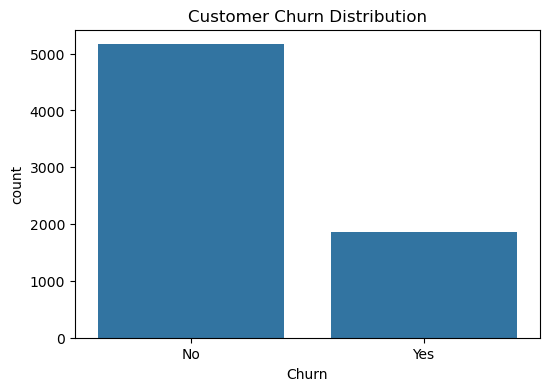

In [31]:
plt.figure(figsize= (6,4))
sns.countplot(x = 'Churn' , data= df)
plt.title('Customer Churn Distribution')
plt.show()


Observation:
Most customers are retained, while a significant portion have churned.
This indicates that customer retention is good, but reducing churn could further improve business revenue.

 Business Recommendation :
The company should identify high-risk customer segments and implement proactive retention strategies to reduce customer churn.

#### Business Question

Does customer gender influence churn behaviour?

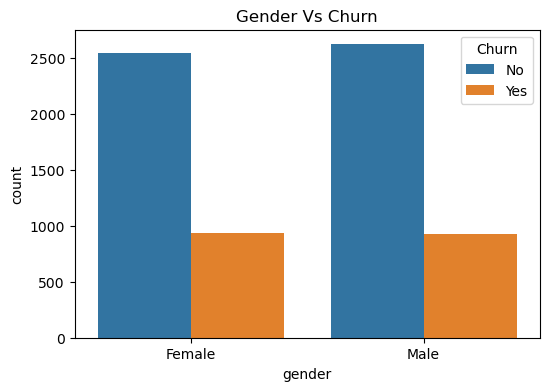

In [44]:
plt.figure(figsize=(6,4))
sns.countplot(x = 'gender' , hue = 'Churn' ,data= df)
plt.title("Gender Vs Churn")
plt.show()

Observation:
Customer churn appears similar across both genders.
Gender alone is not a strong indicator of churn.

Business Recommendation: 
Customer retention strategies should focus on behavioural and service-related factors rather than gender.

#### Business Question

Are senior citizens more likely to churn than non-senior customers?

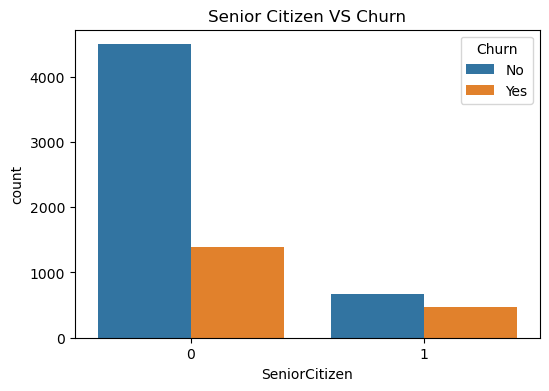

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x = 'SeniorCitizen' , hue= 'Churn' , data=df)
plt.title('Senior Citizen VS Churn')
plt.show()

Observation:
Senior citizens show a relatively higher churn rate compared to non-senior customers.

Business Recommendation: 
Offer customized plans, better customer support, and loyalty programs specifically designed for senior citizens.

#### Business Question

How does the type of customer contract affect churn?

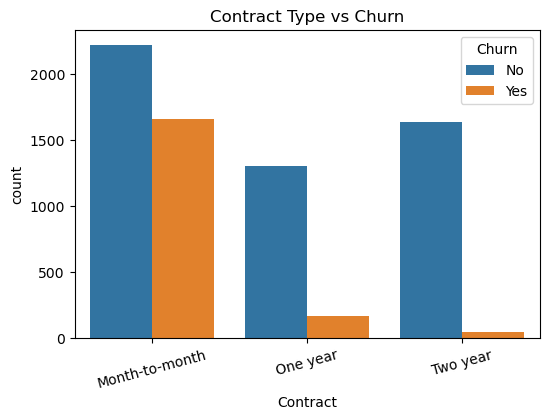

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x = 'Contract', hue= 'Churn' , data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

Observation:
Customers with month-to-month contracts have the highest churn.
Customers with one-year and two-year contracts are much more likely to stay.
Recommendation:
Encourage long-term contracts through discounts or loyalty benefits.

Business Recommendation :
Encourage customers to switch to long-term contracts by offering discounts, loyalty rewards, and exclusive benefits.

#### Business Question

Does the type of internet service influence customer churn?

Text(0.5, 1.0, 'InternetService Vs Churn')

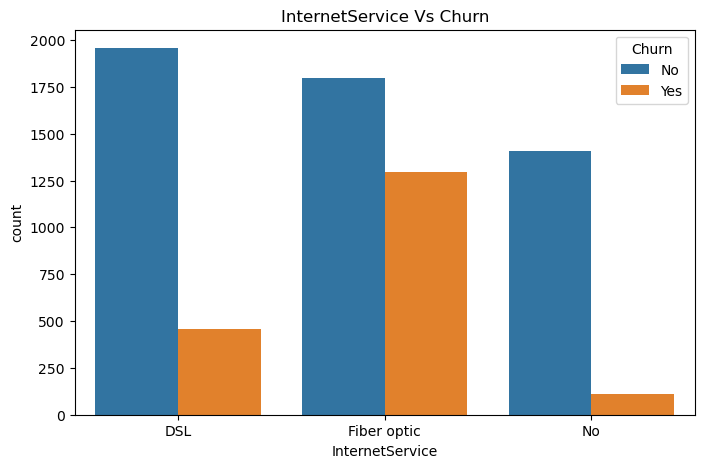

In [59]:
plt.figure(figsize=(8,5))
sns.countplot( x = 'InternetService', hue= 'Churn' , data= df)
plt.title('InternetService Vs Churn')

Observation : 
Customers using Fiber Optic internet service exhibit a higher churn rate compared to DSL users. Customers without internet service show the lowest churn.
This suggests that internet service type is an important factor influencing customer retention.

Business Recommendation :
Investigate service quality, pricing, and customer satisfaction for Fiber Optic users. Improving service reliability may reduce churn.

#### Business Question

Does the customer's payment method influence churn behaviour?

Text(0.5, 1.0, ' Payment Method vs Churn ')

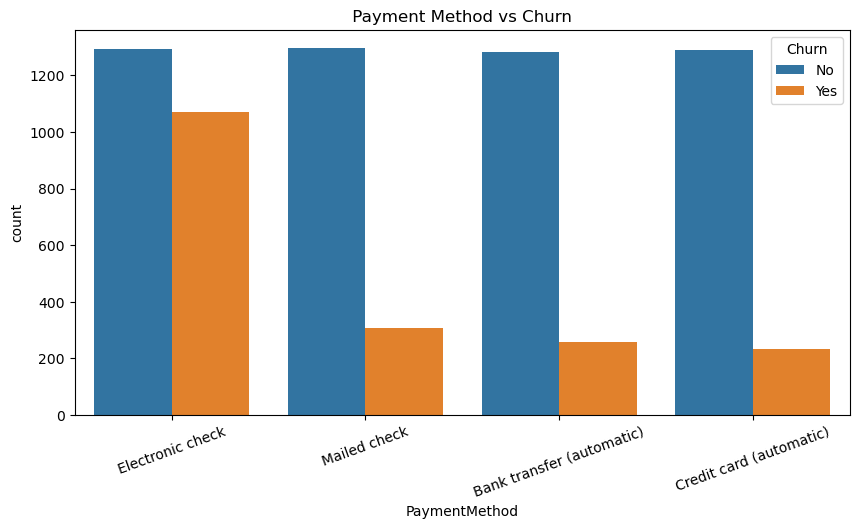

In [63]:
plt.figure(figsize=(10,5))
sns.countplot( x = 'PaymentMethod' , hue= 'Churn' , data= df)
plt.xticks(rotation=20)
plt.title(' Payment Method vs Churn ')

Observation :
Customers using Electronic Check as their payment method experience higher churn compared to customers using automatic payment methods such as Credit Card and Bank Transfer.

Business Recommendation : 
Encourage customers to adopt automatic payment methods by offering incentives and improving the payment experience.

#### Business Question

How are monthly charges distributed among customers?

Text(0.5, 1.0, 'Distribution of Monthly Charges')

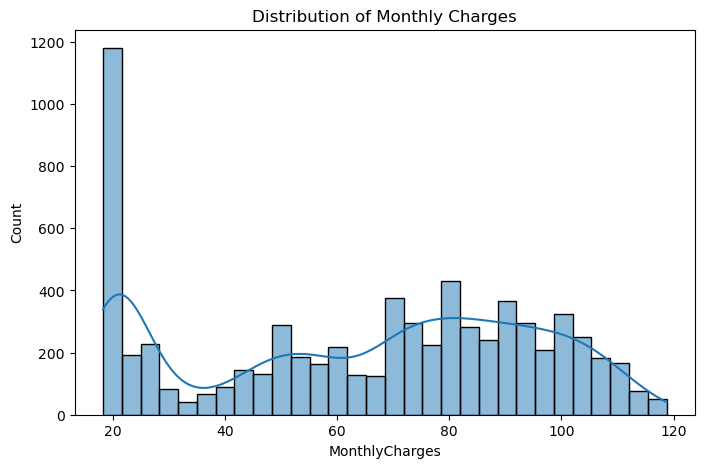

In [69]:
plt.figure( figsize= ( 8,5))
sns.histplot(df['MonthlyCharges'] , bins= 30 , kde= True)
plt.title("Distribution of Monthly Charges")

Observation :
Monthly charges vary across customers, with the majority paying moderate to high subscription fees. The pricing distribution reflects different service plans and customer usage patterns.

Business Recommendation:
Regularly evaluate pricing plans to ensure customers receive good value for the services they purchase.

#### Business Question

Is there a relationship between monthly charges and customer churn?

Text(0.5, 1.0, ' Montly Charges vs Churn')

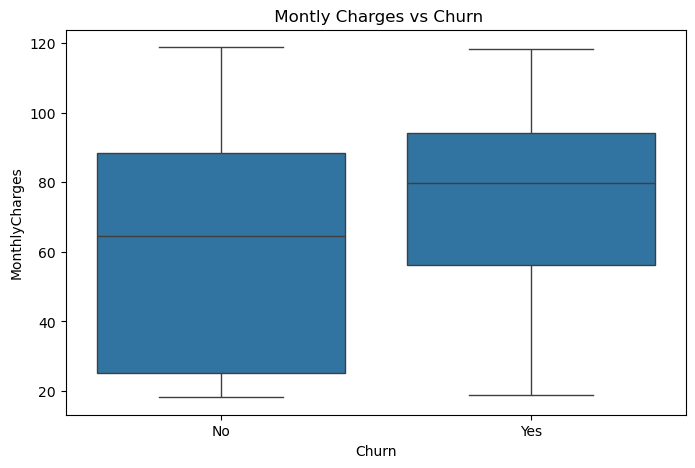

In [96]:
plt.figure(figsize= (8,5))
sns.boxplot( x  = 'Churn' , y = 'MonthlyCharges' , data= df)
plt.title( ' Montly Charges vs Churn')

Observation:
Customers who churn generally pay higher monthly charges than customers who remain with the company. High service costs may encourage customers to switch to competing providers.

Business Recommendation :
Review premium pricing plans and introduce loyalty discounts or bundled service packages to improve customer retention.

#### Business Question

Does customer tenure influence churn behaviour?

Text(0.5, 1.0, 'Tenure vs Churn')

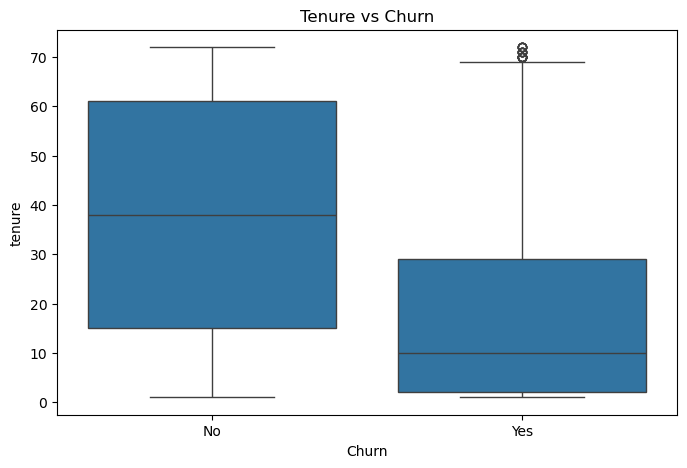

In [72]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")

Observation:
Customers with shorter tenure are much more likely to churn.

Business Recommendation :
Strengthen onboarding, engagement, and customer success programs during the first year to improve long-term retention.

### Feature Engineering

#### Business Question

Which customer tenure group experiences the highest churn?

In [75]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1 Year','1-2 Years','2-4 Years','4-6 Years']
)

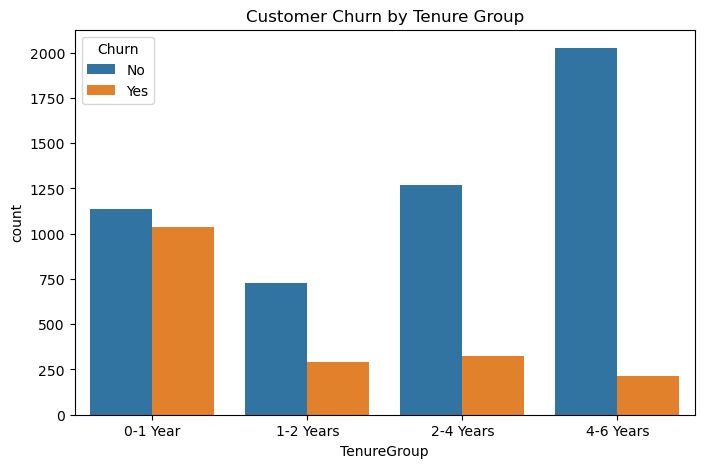

In [76]:
plt.figure(figsize=(8,5))
sns.countplot(x='TenureGroup', hue='Churn', data=df)
plt.title("Customer Churn by Tenure Group")

Observation :
Customers in their first year have the highest churn rate.
Customer retention efforts should focus on new customers.

Business Recommendation :
Focus retention campaigns on new customers by providing onboarding assistance, welcome offers, and regular engagement during their first year.

### Business Insights

#### Insight 1: Customer Churn Distribution

- Most customers remain with the company, but a significant number have churned.
- Customer retention strategies should focus on reducing this churn percentage.

#### Insight 2: Gender Impact

- Male and female customers show similar churn behaviour.
- Gender alone is not a strong predictor of customer churn.

#### Insight 3: Senior Citizens

- Senior citizens have a higher churn rate compared to non-senior customers.
- Personalized support and special plans may help improve retention.

#### Insight 4: Contract Type

- Customers with month-to-month contracts are much more likely to churn.
- Long-term contracts significantly improve customer retention.

#### Insight 5: Monthly Charges

- Customers paying higher monthly charges tend to churn more frequently.
- Competitive pricing and value-added services may reduce churn.

#### Insight 6: Tenure

- Customers with shorter tenure are more likely to leave.
- Early engagement and onboarding programs should be strengthened.

#### Insight 7: Payment Method

- Electronic Check customers show relatively higher churn.
- Investigating payment experience may improve customer satisfaction.

### Recommendations

1. Encourage customers to switch from month-to-month contracts to annual plans through discounts and loyalty rewards.
2. Improve onboarding experience for new customers during the first six months.
3. Review pricing strategy for customers with higher monthly charges.
4. Offer personalized retention campaigns for senior citizens.
5. Improve customer support and technical assistance to increase customer satisfaction.
6. Promote secure and convenient payment methods to improve customer experience.
7. Continuously monitor churn trends using dashboards for proactive decision-making.

### Conclusion

This project analyzed customer churn data to identify the major factors contributing to customer attrition.
The analysis revealed that contract type, tenure, monthly charges, and customer demographics significantly influence churn behaviour.
nsights generated from this project can help businesses improve customer retention strategies, increase customer lifetime value, and make data-driven decisions.

#### Export Cleaned Dataset

The cleaned dataset is exported for future analysis and dashboard development.

In [84]:
df.to_csv("../data/cleaned/Cleaned_Telco_Customer_Churn.csv", index=False)